# Contextual Bandit

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


In [75]:
import numpy as np
import matplotlib.pyplot as plt
from rlcmab_sampler import sampler
from tqdm import tqdm

-0.30789546982218735


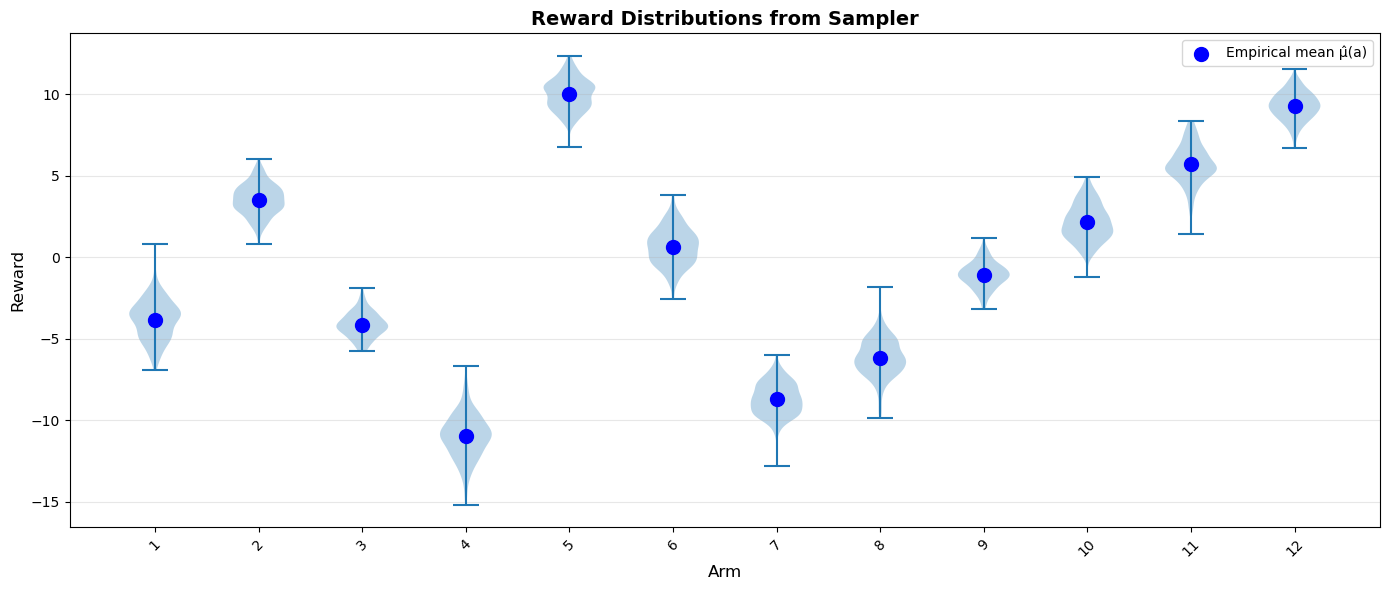

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def plot_arm_reward_distributions(reward_sampler,
                                  arms: int = 12,
                                  samples_per_arm: int = 200) -> None:
    """
    Visualize reward distributions from rlcmab sampler using violin plots.
    """

    # 1️⃣ Create matrix (samples x arms)
    samples_matrix = np.zeros((samples_per_arm, arms))

    # 2️⃣ Collect rewards using sampler.sample(j)
    for trial in range(samples_per_arm):
        for a in range(arms):
            reward = reward_sampler.sample(a)
            samples_matrix[trial, a] = reward

    # 3️⃣ Empirical mean reward
    emp_mean = samples_matrix.mean(axis=0)

    # 4️⃣ Plot violin plots
    fig, ax = plt.subplots(figsize=(14,6))

    parts = ax.violinplot(
        samples_matrix,
        positions=range(arms),
        showmeans=False,
        showmedians=False
    )

    # Plot empirical means
    ax.scatter(range(arms), emp_mean,
               color='blue', s=100, zorder=3,
               label='Empirical mean μ̂(a)', marker='o')

    # nicer labels using your context mapping
    labels = [1, 2, 3, 4, 5,6 ,7 ,8 ,9, 10, 11, 12]

    print(np.mean(emp_mean))

    ax.set_xlabel('Arm', fontsize=12)
    ax.set_ylabel('Reward', fontsize=12)
    ax.set_title('Reward Distributions from Sampler', fontsize=14, fontweight='bold')
    ax.set_xticks(range(arms))
    ax.set_xticklabels(labels, rotation=45)

    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

reward_sampler = sampler(63)

plot_arm_reward_distributions(reward_sampler, samples_per_arm=200)

In [29]:
class BanditAgent:
    """
    An agent that learns to select actions in a k-armed bandit problem.
    """
    
    def __init__(self, k: int, epsilon: float = 0.3, 
                 step_size: float = None, initial_value: float = -0.3, c: float = 2.0, tao: float=0.1):

        self.k = k
        self.epsilon = epsilon
        self.step_size = step_size

        self.c = c
        self.tao = tao
        self.t = 0
        
        self.Q_a = np.ones([k]) * initial_value
        self.N_a = np.zeros([k])

        # print(self.Q_a, self.N_a)        
    
    def epsilon_greedy(self) -> int:
        """Select an action using ε-greedy policy."""
        
        random = np.random.rand()
        if random < self.epsilon:
            action = np.random.randint(self.k)
        else:
            action = np.argmax(self.Q_a)

        # max_value = np.max(self.Q_a)
        # candidates = np.where(self.Q_a == max_value)[0]
        # action = np.random.choice(candidates)    
        
        return action
    
    def ucb(self) -> int:
        """Select an action using ucb policy."""
        
        for a in range(self.k):
            if self.N_a[a] == 0:
                return a

        ucb_values = self.Q_a + self.c * np.sqrt(
            np.log(self.t) / self.N_a
        )

        max_value = np.max(ucb_values)
        candidates = np.where(ucb_values == max_value)[0]
        return np.random.choice(candidates)
    
    def soft_max(self) -> int:

        Q = self.Q_a

        Q_max = np.max(Q)
        Q_stable = Q- Q_max

        pi = np.exp(Q_stable/self.tao)/np.sum(np.exp(Q_stable/self.tao))
        # print(pi)

        return np.argmax(pi)
    
    def update(self, action: int, reward: float):
        """ Update action-value estimates after receiving a reward. """
        self.t += 1
        self.N_a[action] +=1

        if self.step_size is None:
            alpha = 1.0 / self.N_a[action]   
        else:
            alpha = self.step_size           

        self.Q_a[action] = self.Q_a[action] + alpha*(reward - self.Q_a[action])

    
    def reset(self, initial_value: float = 0.0):
        """Reset the agent for a new run."""
        self.Q_a = np.ones([self.k])*initial_value
        self.N_a = np.zeros([self.k])
        self.t = 0


agent = BanditAgent(12)

## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


In [63]:
def run_experiment(epsilon: int=0.1,
                    steps: int = 200):
    """
    Run a single experiment: agent interacting with bandit.
    """
    # agent = BanditAgent(12)
    reward_sampler = sampler(63)

    rewards = np.zeros(steps)

    agents = [
        BanditAgent(4, epsilon=epsilon),
        BanditAgent(4, epsilon=epsilon),
        BanditAgent(4, epsilon=epsilon)
    ]

    for t in range(steps):
            context = np.random.randint(3)
            agent = agents[context]

            local_action = agent.epsilon_greedy()

            # map to global arm
            if context == 0:
                global_action = local_action
            elif context == 1:
                global_action = local_action + 4
            else:
                global_action = local_action + 8

            reward = reward_sampler.sample(global_action)

            agent.update(local_action, reward)

            rewards[t] = reward
    
    return rewards, agents

In [58]:
def train_epsilon(epsilon: float = 0.1,
                steps: int = 10000,
                runs: int = 2000):

    all_rewards = np.zeros((runs, steps))

    for run in range(runs):

        rewards = run_experiment(epsilon, steps)
        all_rewards[run] = rewards

    avg_rewards = all_rewards.mean(axis=0)

    return avg_rewards


[[ -3.83762738   3.453141    -4.40775039 -11.12235999]
 [  9.9224087    0.69377641  -8.99226692  -5.98894462]
 [ -0.907518     2.29916227   5.80480999   9.1932353 ]]


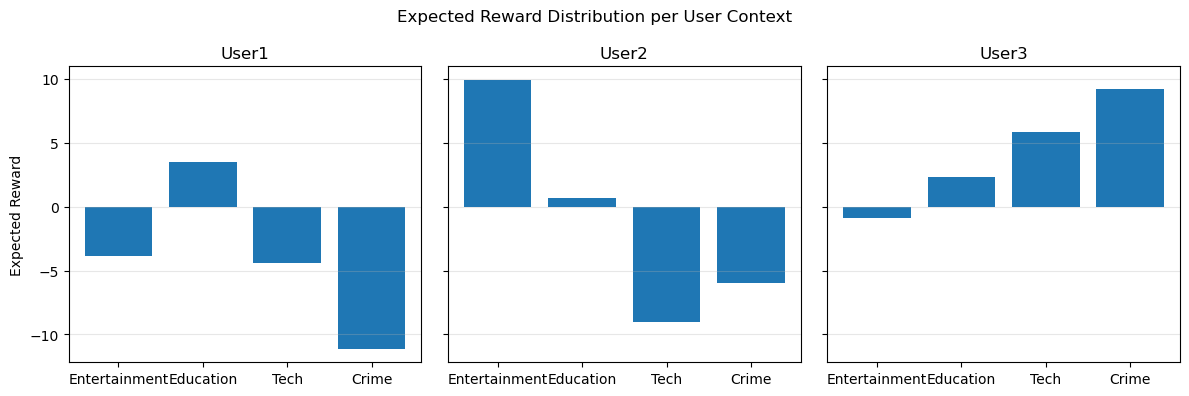

In [93]:
def compute_expected_reward_distribution(epsilon=0.1, steps=5000):

    rewards, agents = run_experiment(epsilon, steps)

    expected_rewards = np.vstack([
        agents[0].Q_a,
        agents[1].Q_a,
        agents[2].Q_a
    ])
    print(expected_rewards)

    return expected_rewards



expected_rewards = compute_expected_reward_distribution(0.1, 5000)
def plot_expected_rewards_bars(expected_rewards):

    news_labels = ["Entertainment","Education","Tech","Crime"]
    users = ["User1","User2","User3"]

    fig, axs = plt.subplots(1, 3, figsize=(12,4), sharey=True)

    for u in range(3):

        axs[u].bar(news_labels, expected_rewards[u])
        axs[u].set_title(users[u])
        # axs[u].set_ylim(0, 1)
        axs[u].grid(axis='y', alpha=0.3)

    axs[0].set_ylabel("Expected Reward")

    plt.suptitle("Expected Reward Distribution per User Context")
    plt.tight_layout()
    plt.show()

plot_expected_rewards_bars(expected_rewards)



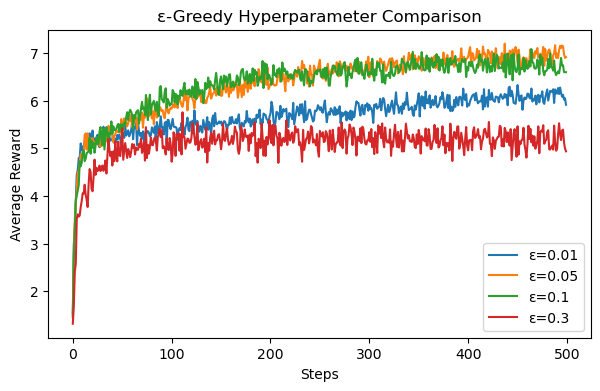

In [61]:
epsilons = [0.01, 0.05, 0.1, 0.3]

plt.figure(figsize=(7,4))

for eps in epsilons:

    avg_rewards = train_epsilon(epsilon=eps, steps=500, runs=1000)
    plt.plot(avg_rewards, label=f"ε={eps}")

plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("ε-Greedy Hyperparameter Comparison")
plt.legend()
plt.show()


In [ ]:
# agent = BanditAgent(12)
# reward_sampler = sampler(63)

# T=200
# for t in range(T):
#     action = agent.epsilon_greedy()
#     reward = reward_sampler.sample(action)
#     agent.update(action, reward)


## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

In [68]:
def run_experiment_ucb(c=2.0, steps=200):

    reward_sampler = sampler(63)
    rewards = np.zeros(steps)

    agents = [
        BanditAgent(4, c=c),
        BanditAgent(4, c=c),
        BanditAgent(4, c=c)
    ]

    for t in range(steps):

        context = np.random.randint(3)
        agent = agents[context]

        local_action = agent.ucb()

        if context == 0:
            global_action = local_action
        elif context == 1:
            global_action = local_action + 4
        else:
            global_action = local_action + 8

        reward = reward_sampler.sample(global_action)
        agent.update(local_action, reward)

        rewards[t] = reward

    return rewards


In [76]:
def train_ucb(c=2.0, steps=5000, runs=200):

    all_rewards = np.zeros((runs, steps))

    for r in tqdm(range(runs), desc=f"UCB (c={c})", leave=False):
        rewards = run_experiment_ucb(steps=steps)
        all_rewards[r] = rewards

    return all_rewards.mean(axis=0)


[[ -3.56036634   3.44583224  -4.13350533 -10.8030425 ]
 [  9.929666     0.75579326  -8.74585944  -6.11622561]
 [ -1.16108277   2.35378022   6.00718439   9.22200792]]


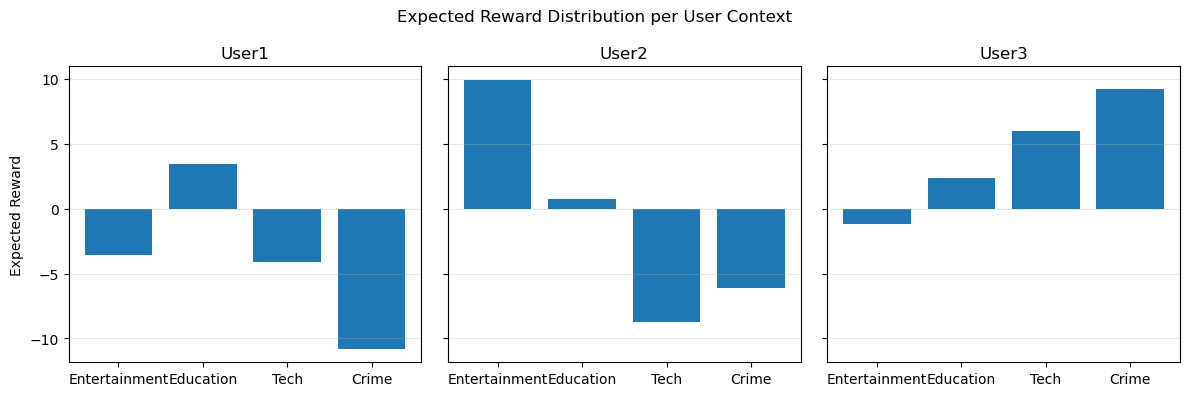

In [94]:
def compute_expected_reward_distribution_ucb(c=0.1, steps=5000):

    rewards, agents = run_experiment(c, steps)

    expected_rewards = np.vstack([
        agents[0].Q_a,
        agents[1].Q_a,
        agents[2].Q_a
    ])
    print(expected_rewards)

    return expected_rewards


expected_rewards = compute_expected_reward_distribution(0.1, 5000)
def plot_expected_rewards_bars(expected_rewards):

    news_labels = ["Entertainment","Education","Tech","Crime"]
    users = ["User1","User2","User3"]

    fig, axs = plt.subplots(1, 3, figsize=(12,4), sharey=True)

    for u in range(3):

        axs[u].bar(news_labels, expected_rewards[u])
        axs[u].set_title(users[u])
        # axs[u].set_ylim(0, 1)
        axs[u].grid(axis='y', alpha=0.3)

    axs[0].set_ylabel("Expected Reward")

    plt.suptitle("Expected Reward Distribution per User Context")
    plt.tight_layout()
    plt.show()

plot_expected_rewards_bars(expected_rewards)



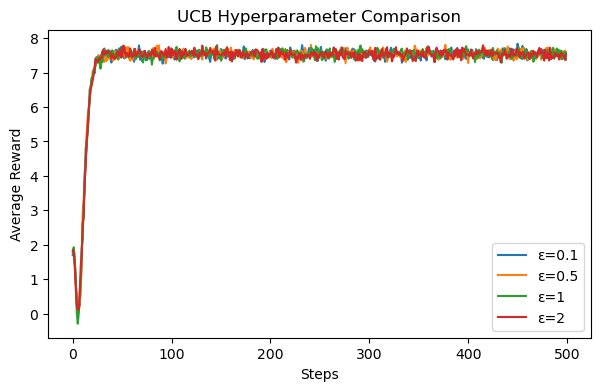

In [77]:
c_options = [0.1, 0.5, 1, 2]

plt.figure(figsize=(7,4))

for c in c_options:

    avg_rewards = train_ucb(c=c, steps=500, runs=1000)
    plt.plot(avg_rewards, label=f"c={c}")

plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("UCB Hyperparameter Comparison")
plt.legend()
plt.show()

## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.

In [70]:
def run_experiment_softmax(tau=0.5, steps=200):

    reward_sampler = sampler(63)
    rewards = np.zeros(steps)

    agents = [
        BanditAgent(4, tao=tau),
        BanditAgent(4, tao=tau),
        BanditAgent(4, tao=tau)
    ]

    for t in range(steps):

        context = np.random.randint(3)
        agent = agents[context]

        local_action = agent.soft_max()

        if context == 0:
            global_action = local_action
        elif context == 1:
            global_action = local_action + 4
        else:
            global_action = local_action + 8

        reward = reward_sampler.sample(global_action)
        agent.update(local_action, reward)

        rewards[t] = reward

    return rewards


In [78]:
def train_softmax(tau=0.5, steps=5000, runs=200):

    all_rewards = np.zeros((runs, steps))

    for r in tqdm(range(runs), desc=f"softmax (t={tau})", leave=False):
        rewards = run_experiment_softmax(tau, steps)
        all_rewards[r] = rewards

    return all_rewards.mean(axis=0)


[[ -4.0691215    3.46356152  -4.3012383  -11.54007565]
 [  9.95898769   0.45127848  -8.89479375  -6.30770004]
 [ -1.17370938   1.94515035   6.00188058   9.20757974]]


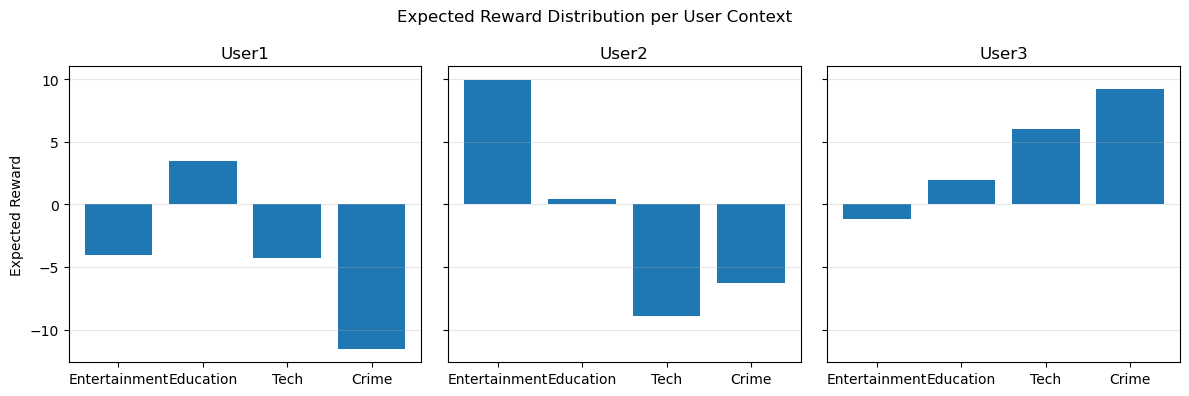

In [95]:
def compute_expected_reward_distribution_softmax(t=1, steps=5000):

    rewards, agents = run_experiment(t, steps)

    expected_rewards = np.vstack([
        agents[0].Q_a,
        agents[1].Q_a,
        agents[2].Q_a
    ])
    print(expected_rewards)

    return expected_rewards


expected_rewards = compute_expected_reward_distribution(0.1, 5000)
def plot_expected_rewards_bars(expected_rewards):

    news_labels = ["Entertainment","Education","Tech","Crime"]
    users = ["User1","User2","User3"]

    fig, axs = plt.subplots(1, 3, figsize=(12,4), sharey=True)

    for u in range(3):

        axs[u].bar(news_labels, expected_rewards[u])
        axs[u].set_title(users[u])
        # axs[u].set_ylim(0, 1)
        axs[u].grid(axis='y', alpha=0.3)

    axs[0].set_ylabel("Expected Reward")

    plt.suptitle("Expected Reward Distribution per User Context")
    plt.tight_layout()
    plt.show()

plot_expected_rewards_bars(expected_rewards)



softmax (t=1):   0%|          | 0/1000 [00:00<?, ?it/s]

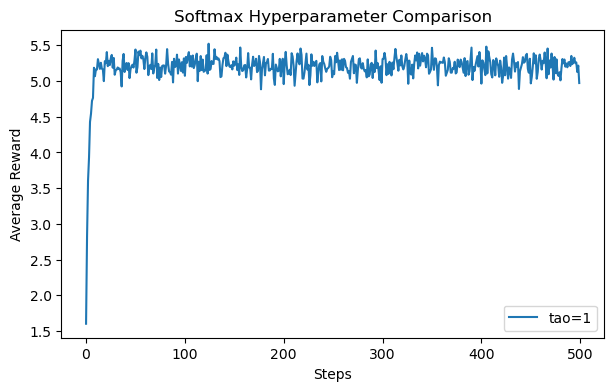

In [83]:
tau = [1]

plt.figure(figsize=(7,4))

for t in tau:

    avg_rewards = train_softmax(tau=t, steps=500, runs=1000)
    plt.plot(avg_rewards, label=f"tao={t}")

plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Softmax Hyperparameter Comparison")
plt.legend()
plt.show()

# Recommendation Engine

In [ ]:
context = classifier.predict(user_features)
agents = [BanditAgent(4), BanditAgent(4), BanditAgent(4)]

agent = agents[context]
category_id = agent.ucb() 

In [ ]:
bandit = MultiArmedBandit(k = 12);
user1_agent = UCBBanditAgent(4, None, 0, 0.1)
user2_agent = UCBBanditAgent(4, None, 0, 0.1)
user3_agent = UCBBanditAgent(4, None, 0, 0.1)
agents = [user1_agent, user2_agent, user3_agent]

steps = 10_000
for t in range(steps):
    for i in range(len(agents)):
        # Select an action
        action_t = agents[i].select_action()
        # Get reward
        action_offset = i * 4;
        reward_t = bandit.pull(action_t + action_offset)
        # Update Q function using the reward
        agents[i].update(action_t, reward_t)

# Sample one point from test_users
sampled_user = test_users.sample(n=1, random_state=102).iloc[0]
print(f"{sampled_user["label"]=}")
user_label = sampled_user["label"]

agent_idx = int(user_label[-1]) - 1

In [ ]:
# Select action from appropriate agent
action = agents[agent_idx].select_action()
if action == 0:
    news_cat = "ENTERTAINMENT"
elif action == 1:
    news_cat = "EDUCATION"
elif action == 2:
    news_cat = "TECH"
elif action == 3:
    news_cat = "CRIME"

print(f"Recommended news category for the user: {news_cat}")

# Sample an article from the recommended category
recommended_articles = news_df[news_df["category"] == news_cat]
sampled_article = recommended_articles.sample(n=1, random_state=102).iloc[0]
sampled_article